In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [135]:
data = pd.read_json("results/yield_1000.json")

print(data["device_count"].value_counts())

data = data[data["device_count"] == 1]
data

device_count
1    1000
Name: count, dtype: int64


,timestamp,time,device_count,prompt_length,max_seq_len,max_tokens,performance_mode,yield_probability,yield_count
0,2025-09-23 03:14:57.551164150,2.565514,1,3653,3653,45,False,0.782800,564
1,2025-09-23 03:15:02.421267509,1.183272,1,1249,1249,15,False,0.838923,199
2,2025-09-23 03:15:07.610841036,1.343912,1,1709,1709,21,False,0.447968,166
3,2025-09-23 03:15:16.162657261,2.576773,1,5518,5518,65,False,0.140662,130
4,2025-09-23 03:15:20.120720148,0.738223,1,465,465,6,False,0.753166,63
...,...,...,...,...,...,...,...,...,...
995,2025-09-23 05:26:03.825738907,0.897042,1,649,649,8,False,0.760072,110
996,2025-09-23 05:26:07.981375217,0.921471,1,577,577,7,False,0.906803,108
997,2025-09-23 05:26:11.581434011,0.564849,1,271,271,3,False,0.211391,17
998,2025-09-23 05:26:15.226919174,0.617787,1,381,381,5,False,0.225430,15


/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packa

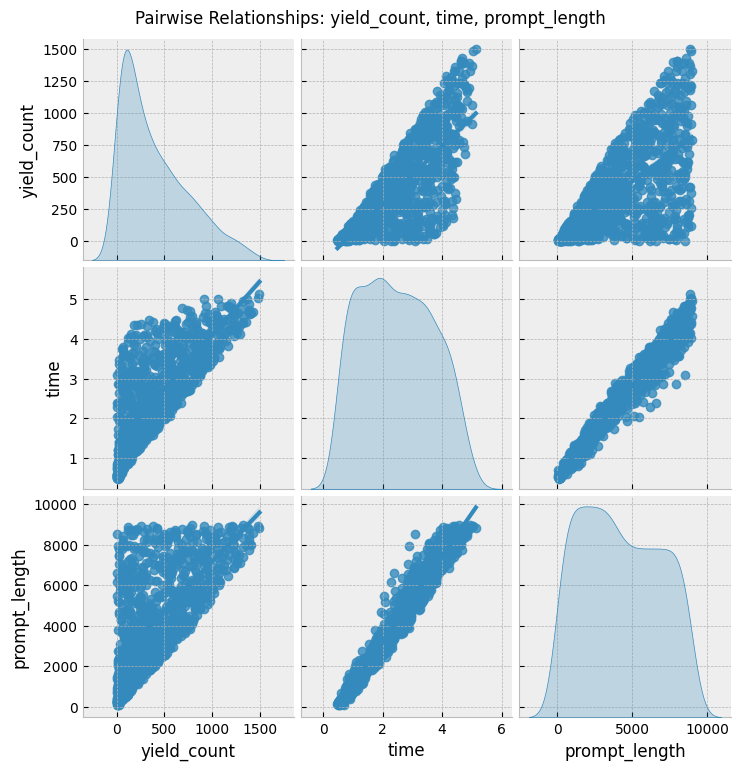

Correlation matrix:
                yield_count      time  prompt_length
yield_count       1.000000  0.778988       0.652489
time              0.778988  1.000000       0.977429
prompt_length     0.652489  0.977429       1.000000


In [136]:
import seaborn as sns

# Select relevant columns
corr_data = data[["yield_count", "time", "prompt_length"]]

# Pairplot to visualize relationships
sns.pairplot(corr_data, kind="reg", diag_kind="kde")
plt.suptitle("Pairwise Relationships: yield_count, time, prompt_length", y=1.02)
plt.show()

# Display correlation matrix
corr_matrix = corr_data.corr()
print("Correlation matrix:\n", corr_matrix)

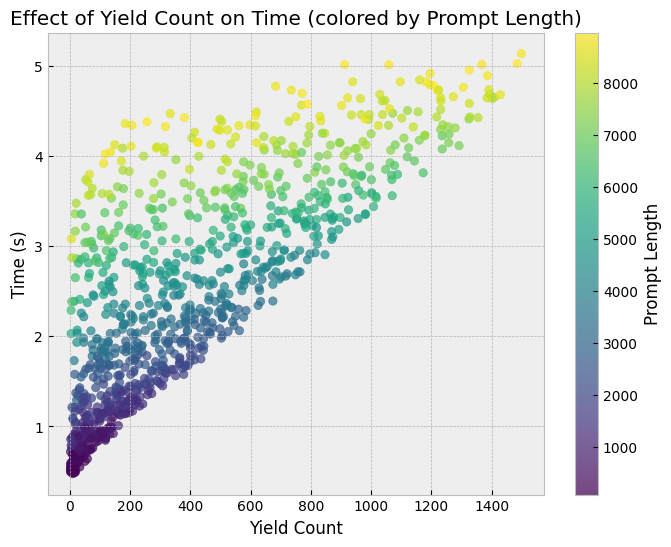

In [137]:
# Scatter plot: yield_count vs time, colored by prompt_length
plt.figure(figsize=(8, 6))
sc = plt.scatter(data["yield_count"], data["time"], c=data["prompt_length"], cmap="viridis", alpha=0.7)
plt.xlabel("Yield Count")
plt.ylabel("Time (s)")
plt.title("Effect of Yield Count on Time (colored by Prompt Length)")
cbar = plt.colorbar(sc)
cbar.set_label("Prompt Length")
plt.show()

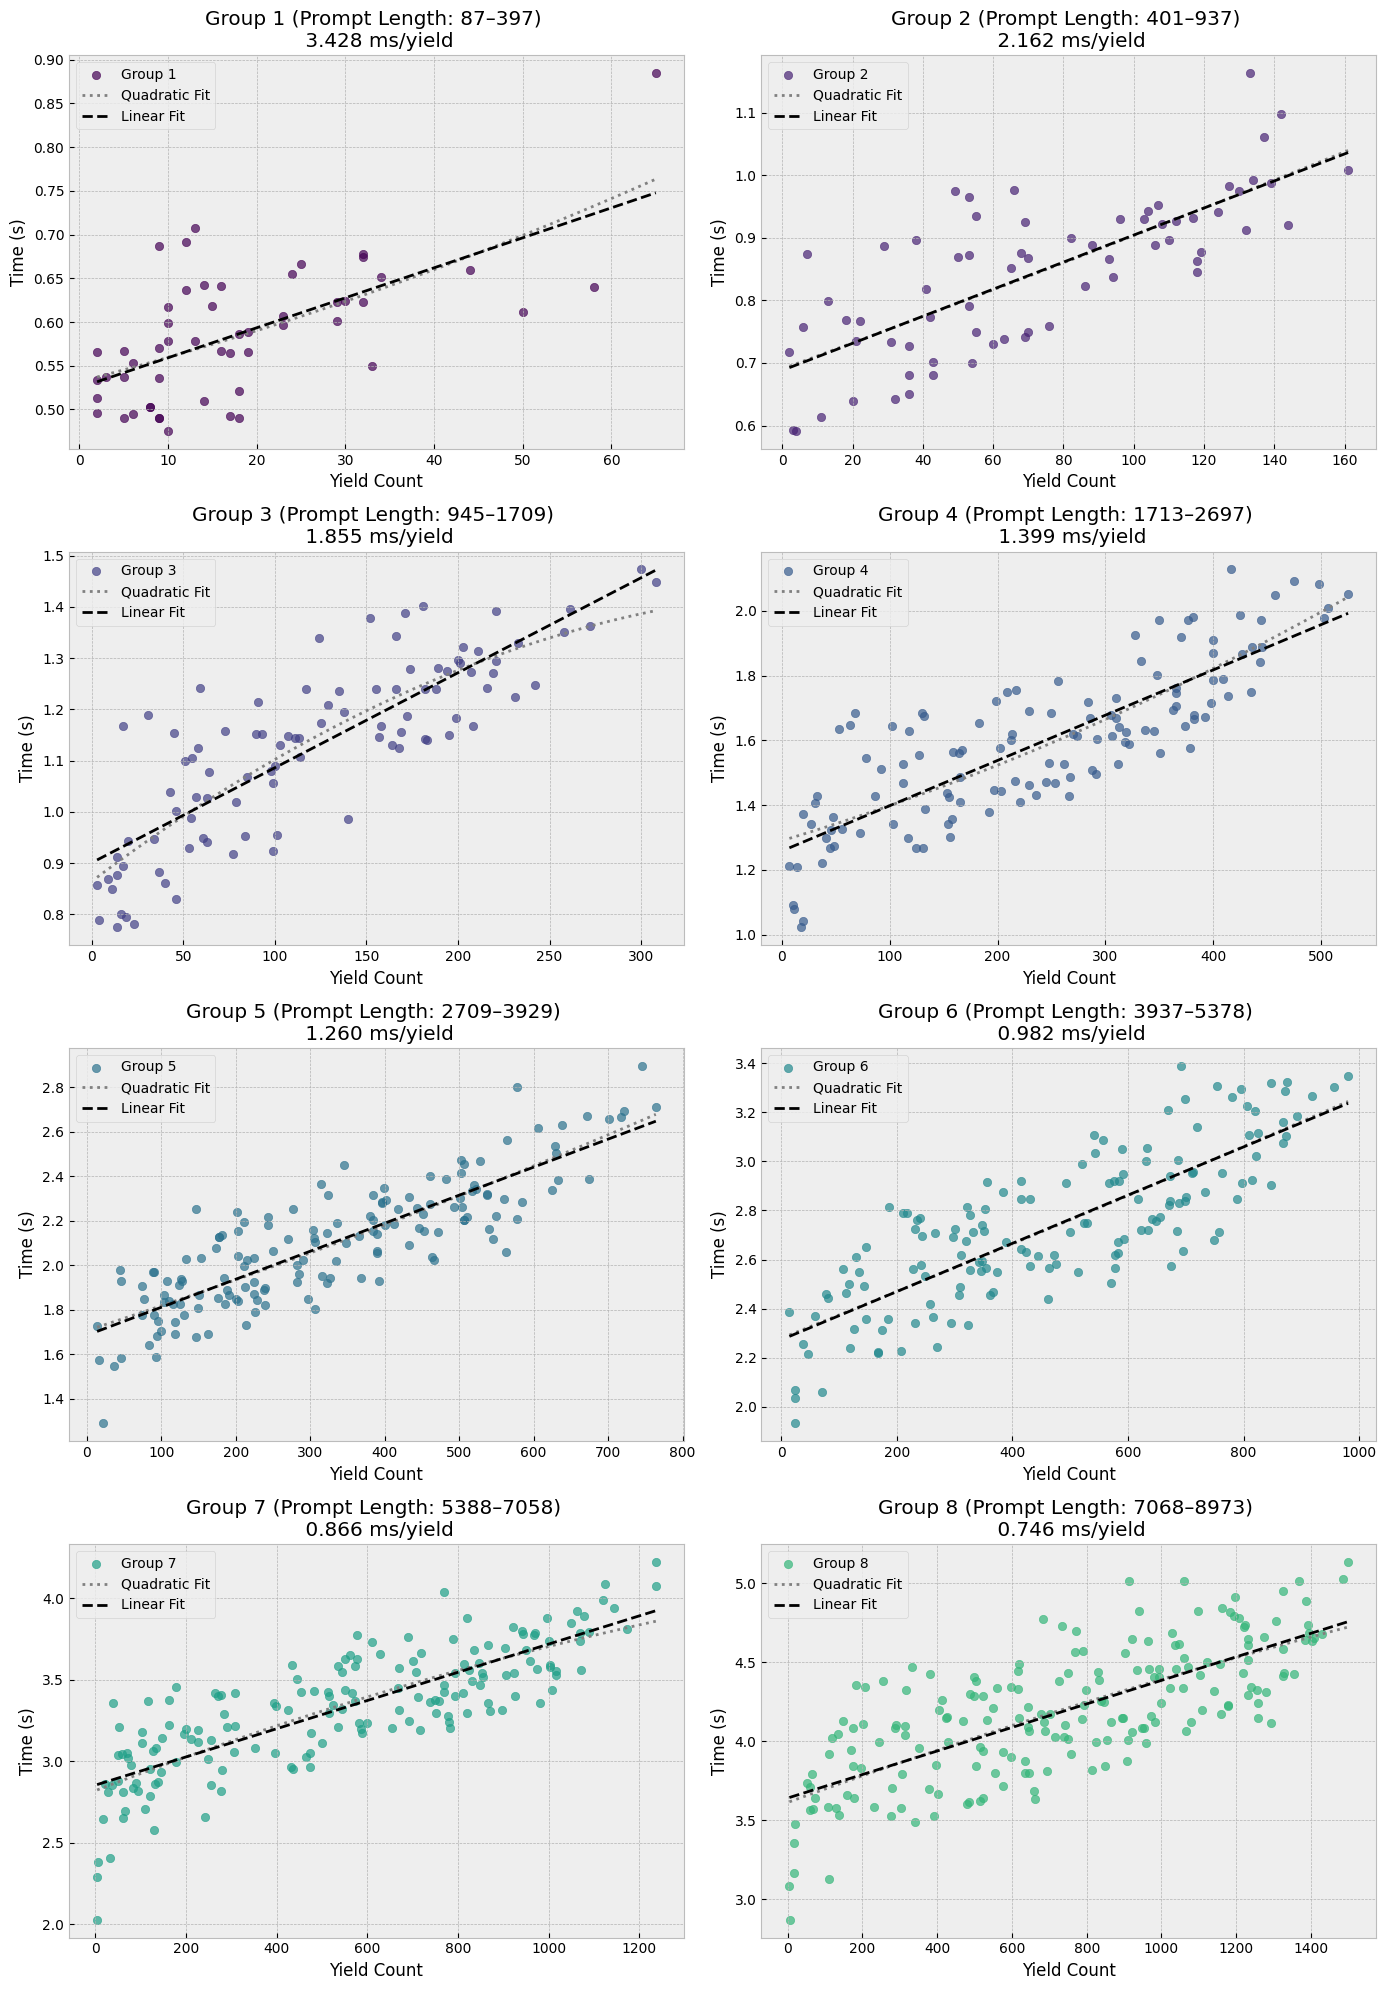

In [138]:
from scipy.optimize import curve_fit


def fit_quad(x, a, b, c):
    return a * x**2 + b * x + c


def fit_lin(x, a, b):
    return a * x + b


# Custom bin edges for linearly increasing group sizes
pl_min = data["prompt_length"].min()
pl_max = data["prompt_length"].max()
num_groups = 8

# Calculate bin edges so each bin covers a linearly increasing range
edges = np.linspace(np.sqrt(pl_min), np.sqrt(pl_max), num_groups + 1)
edges = np.round(edges**2).astype(int)

data["pl_group"] = pd.cut(data["prompt_length"], bins=edges, labels=False, include_lowest=True)

fig, axes = plt.subplots(num_groups // 2, 2, figsize=(14, 5 * num_groups // 2), sharex=False, sharey=False)
axes = axes.flatten()

for group_id in range(num_groups):
    ax = axes[group_id]
    group = data[data["pl_group"] == group_id]
    x = group["yield_count"]
    y = group["time"]
    color = colors[group_id * 120 // num_groups]  # pick well-separated colors
    ax.scatter(x, y, label=f"Group {group_id + 1}", color=color, alpha=0.7)
    if len(x) > 2:
        try:
            popt, _ = curve_fit(fit_quad, x, y)
            x_fit = np.linspace(x.min(), x.max(), 100)
            y_fit = fit_quad(x_fit, *popt)
            ax.plot(x_fit, y_fit, color="gray", linestyle=":", label="Quadratic Fit")

            popt_lin, _ = curve_fit(fit_lin, x, y)
            y_fit_lin = fit_lin(x_fit, *popt_lin)

            slope = f"{(popt_lin[0] * 1_000):.3f}"
            ax.plot(x_fit, y_fit_lin, color="black", linestyle="--", label="Linear Fit")
        except Exception:
            pass

    # Get prompt length range for this group
    if not group.empty:
        pl_min = group["prompt_length"].min()
        pl_max = group["prompt_length"].max()
        pl_range = f"Prompt Length: {pl_min}–{pl_max}"
    else:
        pl_range = "Prompt Length: N/A"
    ax.set_title(f"Group {group_id + 1} ({pl_range}) \n {slope} ms/yield")
    ax.set_xlabel("Yield Count")
    ax.set_ylabel("Time (s)")
    ax.legend()

plt.tight_layout()
plt.show()


In [139]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# assume df has: time, yield_count, prompt_size
df = data.copy()
X0 = df[['yield_count']].values
X1 = df[['yield_count', 'prompt_length']].values
y  = df['time'].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_metrics(X, y):
    rmses, maes = [], []
    for train_idx, test_idx in kf.split(X):
        model = LinearRegression().fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])
        rmses.append(np.sqrt(mean_squared_error(y[test_idx], pred)))
        maes.append(mean_absolute_error(y[test_idx], pred))
    return np.mean(rmses), np.mean(maes)

rmse0, mae0 = cv_metrics(X0, y)
rmse1, mae1 = cv_metrics(X1, y)

print("Yield-only model:", rmse0, mae0)
print("Yield+prompt model:", rmse1, mae1)
print("Relative RMSE diff (%)", (rmse0 - rmse1) / rmse1 * 100)



Yield-only model: 0.7546153117702274 0.6109934151464433
Yield+prompt model: 0.11954719673032406 0.08869881852931279
Relative RMSE diff (%) 531.2279437823183
